# 7 · Leaderboard final y conclusiones

Cierre: reunimos todos los modelos en un **leaderboard** y sacamos las conclusiones.
Incluimos **DeepSVDD** como referencia de un método moderno de deep anomaly detection
(librería `deepod`), a presupuesto parejo (300 épocas, capacidad como el VAE).

> **Sobre los métodos modernos:** probamos también ICL y NeuTraL, pero con presupuesto
> parejo y sin tuning específico dieron **por debajo del baseline** (ICL) o **cerca del
> azar** (NeuTraL) — no aportan a la comparación, así que dejamos solo DeepSVDD (el
> mejor de los tres) como referencia. No los tuneamos a fondo porque el **techo estructural**
> (nb 5) los limita igual: no hay señal extra que exprimir.

In [1]:
import lab                      # utilidades: métricas y gráficos (experiments/lab.py)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import config, data
from src.models import (IsolationForestDetector, OneClassSVMDetector,
                        AEDetector, DenoisingAEDetector, VAEDetector,
                        EnsembleDetector, DeepODDetector)
plt.rcParams["figure.dpi"] = 110
SEEDS = lab.SEEDS            # 10 semillas del estudio. Bajalas (p. ej. [42,43,44])
print("semillas:", SEEDS)   # para un Run all más rápido; los números se mueven ±std

semillas: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]


In [2]:
panel_z = data.prepare()                         # panel + etiqueta z_rinde
ds   = data.build_crop_dataset(panel_z, "soja")  # split + normalización (soja)
dsm  = data.build_crop_dataset(panel_z, "maiz")  # idem maíz
print("soja  train:", ds.X_train.shape, "| test anómalas:", int(ds.y_test.sum()))
print("maíz  train:", dsm.X_train.shape, "| test anómalas:", int(dsm.y_test.sum()))

[data] dedup panel: 28683 → 21418 filas (7265 duplicados espurios por lat/lon eliminados)


soja  train: (6377, 54) | test anómalas: 257
maíz  train: (8347, 54) | test anómalas: 349


## 7.1 · Leaderboard final
Entrenamos cada modelo clave acá mismo. El **modelo final** es el seed-ensemble ×10 del VAE
`recon_prob` (config ganadora `(128,64) lat24`, nb 3) **+ ERA5+NDVI** (nb 6). Todo
multi-seed; OCSVM es determinista (std 0).

[data] dedup panel: 28683 → 21418 filas (7265 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 28683 → 21418 filas (7265 duplicados espurios por lat/lon eliminados)


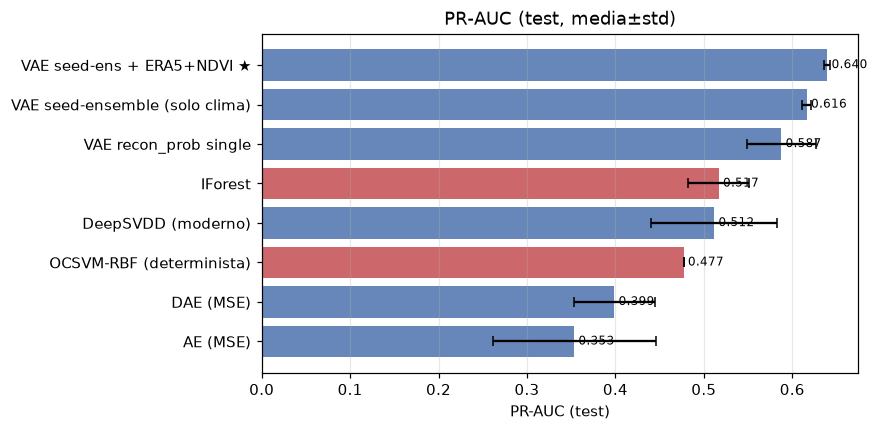

,modelo,pr_auc,pr_auc_std,roc_auc
0,VAE seed-ens + ERA5+NDVI ★,0.640,0.003,0.783
1,VAE seed-ensemble (solo clima),0.616,0.005,0.756
2,VAE recon_prob single,0.587,0.039,0.737
3,IForest,0.517,0.034,0.696
4,DeepSVDD (moderno),0.512,0.072,0.759
5,OCSVM-RBF (determinista),0.477,0.000,0.706
6,DAE (MSE),0.399,0.046,0.659
7,AE (MSE),0.353,0.092,0.579


In [3]:
# --- panel con ERA5+NDVI (para el modelo final) ---
panel_ndvi = data.prepare(config.PANEL_NDVI_PATH, use_ndvi=True)
er = data.load_panel(config.PANEL_ERA5_PATH, use_era5=True)
key = ["provincia","departamento","campania_inicio","cultivo"]
panel_combo = data.compute_z_rinde(panel_ndvi.merge(er[key+config.ERA5_COLS], on=key, how="left"))
ds_combo = data.build_crop_dataset(panel_combo, "soja", use_ndvi=True, use_era5=True)

def ens_scores(dset, base):
    miembros = [VAEDetector(hidden_dims=(128,64), latent_dim=24, score_mode="recon_prob",
                n_mc_samples=50, max_epochs=300, patience=30, random_state=base+i) for i in range(10)]
    return EnsembleDetector(miembros).fit(dset.X_train).score_samples(dset.X_test)

lb = lab.leaderboard({
  "VAE seed-ens + ERA5+NDVI ★": [lab.metrics(ens_scores(ds_combo, b), ds_combo.y_test) for b in [42,52,62]],
  "VAE seed-ensemble (solo clima)": [lab.metrics(ens_scores(ds, b), ds.y_test) for b in [42,52,62]],
  "VAE recon_prob single": [lab.metrics(VAEDetector(hidden_dims=(128,64), latent_dim=24,
        score_mode="recon_prob", n_mc_samples=50, max_epochs=300, patience=30, random_state=s)
        .fit(ds.X_train).score_samples(ds.X_test), ds.y_test) for s in SEEDS],
  "AE (MSE)": [lab.metrics(AEDetector(hidden_dims=(128,64), latent_dim=24, score_mode="mse",
        max_epochs=300, patience=30, random_state=s)
        .fit(ds.X_train).score_samples(ds.X_test), ds.y_test) for s in SEEDS],
  "DAE (MSE)": [lab.metrics(DenoisingAEDetector(hidden_dims=(128,64), latent_dim=24, score_mode="mse",
        max_epochs=300, patience=30, random_state=s)
        .fit(ds.X_train).score_samples(ds.X_test), ds.y_test) for s in SEEDS],
  "IForest": [lab.metrics(IsolationForestDetector(n_estimators=200, max_features=0.3, random_state=s)
        .fit(ds.X_train).score_samples(ds.X_test), ds.y_test) for s in SEEDS],   # estocástico → std
  "DeepSVDD (moderno)": [lab.metrics(DeepODDetector(algo="deepsvdd", epochs=300, batch_size=64,
        lr=1e-3, random_state=s, rep_dim=16, hidden_dims="64,32")
        .fit(ds.X_train).score_samples(ds.X_test), ds.y_test) for s in SEEDS],
  "OCSVM-RBF (determinista)": [lab.metrics(OneClassSVMDetector(kernel="rbf", nu=0.1)
        .fit(ds.X_train).score_samples(ds.X_test), ds.y_test)],                   # 1 corrida → std 0
})
lab.plot_leaderboard(lb); plt.show()
lb[["modelo","pr_auc","pr_auc_std","roc_auc"]].round(3)

## 7.2 · Recapitulación del recorrido
La historia en una tabla. Los **PR-AUC salen del leaderboard vivo de arriba** (`lb`, celda
7.1) — no hay ningún número escrito a mano: si cambiás las semillas o el pipeline, esta tabla
se mueve sola con la corrida.

In [4]:
pr = dict(zip(lb["modelo"], lb["pr_auc"]))   # PR-AUC reales, tomados del leaderboard 7.1
recap = pd.DataFrame([
    ("nb1", "Isolation Forest (baseline)",        pr["IForest"],                       "listón no neuronal, varianza baja"),
    ("nb1", "One-Class SVM (RBF)",                pr["OCSVM-RBF (determinista)"],       "kernel gaussiano ≈ IForest; el lineal fracasa (nb1)"),
    ("nb2", "AE (score MSE)",                     pr["AE (MSE)"],                       "el MSE plano no alcanza"),
    ("nb2", "DAE (score MSE)",                    pr["DAE (MSE)"],                      "el denoising no cambia el cuello de botella"),
    ("nb3", "VAE recon_prob (single)",            pr["VAE recon_prob single"],          "el SCORE probabilístico es el salto vs MSE"),
    ("nb4", "VAE seed-ensemble ×10 (solo clima)", pr["VAE seed-ensemble (solo clima)"], "baja la varianza y sube la media"),
    ("nb6", "seed-ensemble + ERA5+NDVI ★",        pr["VAE seed-ens + ERA5+NDVI ★"],     "MODELO FINAL: suelo+verdor mejoran (significativo)"),
    ("nb7", "DeepSVDD (moderno)",                 pr["DeepSVDD (moderno)"],             "a presupuesto parejo, por debajo del VAE"),
], columns=["nb", "etapa", "PR-AUC soja (test)", "conclusión"])
recap["PR-AUC soja (test)"] = recap["PR-AUC soja (test)"].round(3)
recap

,nb,etapa,PR-AUC soja (test),conclusión
0,nb1,Isolation Forest (baseline),0.517,"listón no neuronal, varianza baja"
1,nb1,One-Class SVM (RBF),0.477,kernel gaussiano ≈ IForest; el lineal fracasa ...
2,nb2,AE (score MSE),0.353,el MSE plano no alcanza
3,nb2,DAE (score MSE),0.399,el denoising no cambia el cuello de botella
4,nb3,VAE recon_prob (single),0.587,el SCORE probabilístico es el salto vs MSE
5,nb4,VAE seed-ensemble ×10 (solo clima),0.616,baja la varianza y sube la media
6,nb6,seed-ensemble + ERA5+NDVI ★,0.640,MODELO FINAL: suelo+verdor mejoran (significat...
7,nb7,DeepSVDD (moderno),0.512,"a presupuesto parejo, por debajo del VAE"


## Conclusiones del Componente A
1. **Modelo final: seed-ensemble ×10 del VAE `recon_prob` + ERA5+NDVI** — el mejor del
   leaderboard de arriba (7.1) y con el menor desvío.
2. **Tres decisiones** lo explican: el **score probabilístico** `recon_prob` (aplasta al
   MSE, nb 3); el **ensemble de semillas** que baja fuerte la varianza (nb 4); y sumar
   **ERA5+NDVI** (estado de suelo + verdor), cuya mejora chica **solo se ve** una vez
   que el ensemble quita el ruido entre semillas (nb 6).
3. **Lección metodológica central:** reportar la varianza multi-seed no es un detalle — sin
   ella, la mejora real de ERA5+NDVI quedaba enterrada en el ruido de los modelos single.
4. Alternativas refutadas: AE/DAE con MSE, detectores sobre el latente (nb 2–4), `agro` y
   `NDVI`-solo (nb 6), y el deep AD moderno a presupuesto parejo (nb 7).
5. **Techo estructural (nb 5):** existe (rondamos ~0.6), la mayoría de las
   anomalías siguen sin firma observable. Pero **no es infranqueable**: suelo+verdor lo
   corren un poco. Superarlo más requeriría **otra clase de datos** (sanidad, granizo, manejo).